In [130]:
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from glob import glob
import re
from collections import defaultdict
import logging
import glob


# Load metadata

In [4]:
with zipfile.ZipFile("./output/retrieved_df/retrieved_df2.json.zip", "r") as z:
    for filename in z.namelist():
        with z.open(filename) as f:
            data = f.read()
            data = json.loads(data)


f.close()
z.close()
metadata_retrieved_df = pd.read_json(data, orient='index')
metadata_retrieved_df.pmid = metadata_retrieved_df.pmid.astype(str)
print(metadata_retrieved_df.columns)

Index(['pmid', 'pmcid', 'title', 'abstract', 'mesh', 'keywords', 'authors',
       'journal', 'pub_type', 'pub_date', 'doi', 'issn', 'crossref',
       'full_text_links', 'licenses', 'pdf', 'xml', 'html', 'plain', 'pmc_tgz',
       'xml_parse_d', 'html_parse_d', 'pdf_parse_d', 'plain_parse_d',
       'content_text'],
      dtype='object')


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95593/368234517.py:10: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  metadata_retrieved_df = pd.read_json(data, orient='index')


In [6]:
metadata_retrieved_df.shape

(300, 25)

In [8]:
metadata_retrieved_df.head()

,pmid,pmcid,title,abstract,mesh,keywords,authors,journal,pub_type,pub_date,...,pdf,xml,html,plain,pmc_tgz,xml_parse_d,html_parse_d,pdf_parse_d,plain_parse_d,content_text
884644d359df46f59ed24980bcf60834,2232487,None,Role of enhanced glomerular synthesis of throm...,Normotensive rats of the Milan strain (MNS) sp...,"[Animals, Glomerulosclerosis, Focal Segmental/...",None,"[Salvati P, Ferti C, Ferrario RG, Lamberti E, ...",Kidney international,"[Journal Article, Research Support, Non-U.S. G...",1990-09-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/884644d35...,1
a068866a075b434d9331a4951ba37ff5,2718779,None,Treatment of congenital osteopetrosis in the r...,Osteopetrosis is a congenital metabolic bone d...,"[Animals, Body Weight, Bone and Bones/diagnost...",None,"[Popoff SN, McGuire JL, Zerwekh JE, Marks SC Jr]",Journal of bone and mineral research : the off...,"[Journal Article, Research Support, Non-U.S. G...",1989-02-26,...,0,0,0,0,0,{},{},{},{},0
98e4bfa4011d408cabba6691b2f69023,6208337,None,DNA changes in spinal cords of rats with exper...,DNA levels were measured in the spinal cords o...,"[Animals, Aspartic Acid Endopeptidases, DNA/*m...",None,"[Smith ME, Somera FP, Saldivar R, Massacesi L,...",Journal of neurochemistry,"[Journal Article, Research Support, Non-U.S. G...",1984-12-26,...,0,0,0,0,0,{},{},{},{},0
4b5ebbd9fed2419786d2ce322dd65069,7593554,None,Additive effects of copolymer-1 and interferon...,Copolymer-1 (Cop-1) inhibits the T cell respon...,"[Antigen-Presenting Cells/immunology, Cell Lin...",None,"[Milo R, Panitch H]",Journal of neuroimmunology,"[Journal Article, Research Support, Non-U.S. G...",1995-09-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/4b5ebbd9f...,1
58b8d364559a4dc48232aaabf8343768,7595604,None,Pharmacokinetics and tolerability of ventricul...,The discovery of mutations in the gene for Cu/...,[Amyotrophic Lateral Sclerosis/*drug therapy/g...,None,"[Smith RA, Balis FM, Ott KH, Elsberry DD, Sher...",Journal of the neurological sciences,"[Clinical Trial, Journal Article]",1995-05-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/58b8d3645...,1


In [10]:
# Make sure these columns are numeric (coerce errors if needed)
cols_to_sum = ['pdf', 'xml', 'html', 'plain', 'content_text']
metadata_retrieved_df[cols_to_sum] = metadata_retrieved_df[cols_to_sum].apply(pd.to_numeric, errors='coerce')

# Calculate total sum of each column
total_sums = metadata_retrieved_df[cols_to_sum].sum()

# Print the result
print(total_sums)

pdf             121
xml              69
html             52
plain            84
content_text    216
dtype: int64


In [12]:
# Count how many of the 5 formats are available per row
metadata_retrieved_df['format_count'] = metadata_retrieved_df[['pdf', 'xml', 'html', 'plain']].sum(axis=1)

# Preview rows where more than 1 format is present
multi_format_df = metadata_retrieved_df[metadata_retrieved_df['format_count'] > 1]

print(f"Number of articles with multiple formats: {len(multi_format_df)}")
print(multi_format_df[['pmid', 'format_count'] + cols_to_sum].head())

Number of articles with multiple formats: 83
                                      pmid  format_count  pdf  xml  html  \
9cc236101265495b87a2507e0b56c527  11306603             2    1    0     1   
d3c258b675ff4563818cae9c6f8590b4  15557109             2    1    0     1   
8f1c69bcbf8a43ce9626a872db6d0b5e  16951693             2    1    0     1   
d25e9c25222a4ec3b40435beb8983fbb  17634127             3    1    1     1   
3d7cda8e7f2f4adfb7c988c0343c2203  17676050             2    1    0     1   

                                  plain  content_text  
9cc236101265495b87a2507e0b56c527      0             1  
d3c258b675ff4563818cae9c6f8590b4      0             1  
8f1c69bcbf8a43ce9626a872db6d0b5e      0             1  
d25e9c25222a4ec3b40435beb8983fbb      0             1  
3d7cda8e7f2f4adfb7c988c0343c2203      0             1  


In [14]:
only_plain_df = metadata_retrieved_df[
    (metadata_retrieved_df['plain'] == 1) &
    (metadata_retrieved_df[['pdf', 'xml', 'html']].sum(axis=1) == 0)
]

print(f"Number of articles with only 'plain' format: {len(only_plain_df)}")

Number of articles with only 'plain' format: 78


In [16]:
only_plain_df = metadata_retrieved_df[
    (metadata_retrieved_df['pdf'] == 1) &
    (metadata_retrieved_df[['plain', 'xml', 'html']].sum(axis=1) == 0)
]

print(f"Number of articles with only 'plain' format: {len(only_plain_df)}")

Number of articles with only 'plain' format: 38


In [23]:
zip_files = glob("output/formats/pdfs/*.zip")  # Replace with your actual path
print(f"Number of ZIP files: {len(zip_files)}")

Number of ZIP files: 121


### proportion with content over time

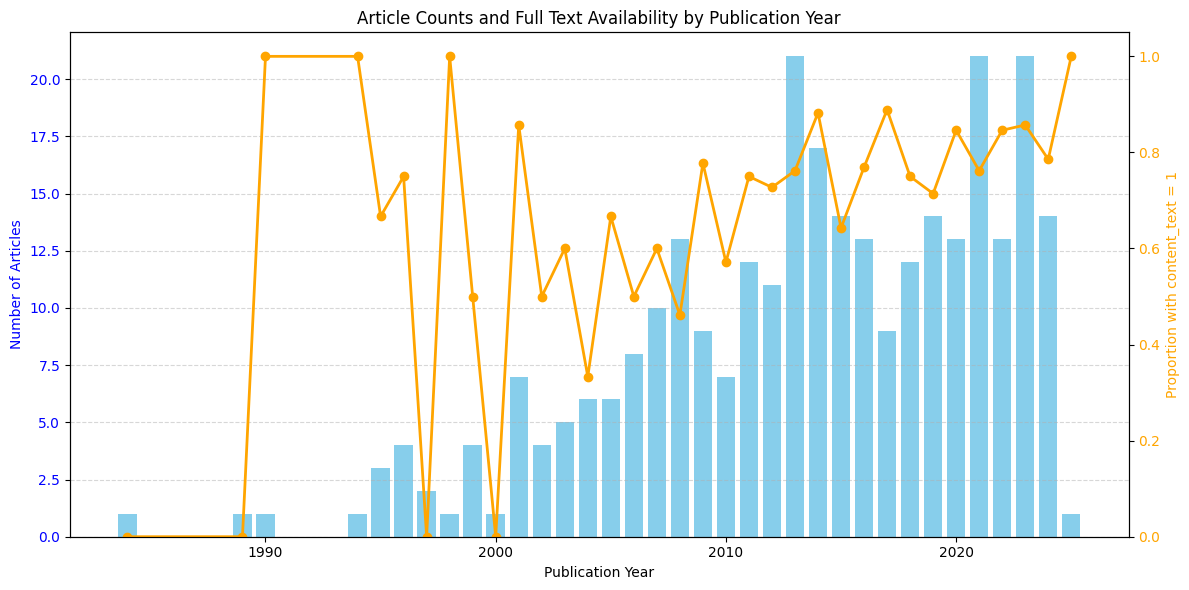

In [26]:
# Prep data
df = metadata_retrieved_df.copy()
df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce')
df['pub_year'] = df['pub_date'].dt.year
df['content_text'] = pd.to_numeric(df['content_text'], errors='coerce')

grouped = df.groupby('pub_year')
year_distribution = grouped.size()
content_proportion = grouped['content_text'].mean()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart (article count)
bars = ax1.bar(year_distribution.index, year_distribution.values, color='skyblue', label='Article Count')
ax1.set_xlabel('Publication Year')
ax1.set_ylabel('Number of Articles', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart (proportion with content_text = 1)
ax2 = ax1.twinx()
line = ax2.plot(content_proportion.index, content_proportion.values, color='orange', marker='o', linewidth=2, label='Proportion with content_text = 1')
ax2.set_ylabel('Proportion with content_text = 1', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, 1.05)  # force full proportion scale for better visibility

# Title and layout
plt.title('Article Counts and Full Text Availability by Publication Year')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()


### count no content/journal

In [29]:
no_content_df = df[df['content_text'] == 0]
print(no_content_df.shape)
# Count PMIDs per journal (assuming 'PMID' and 'JT' columns exist)
pmid_counts_per_journal = no_content_df.groupby('journal')['pmid'].count().sort_values(ascending=False)

# Show the result
print(pmid_counts_per_journal.head(10))  # Top 10 journals

(84, 27)
journal
Journal of immunology (Baltimore, Md. : 1950)                                                            6
The Journal of neuroscience : the official journal of the Society for Neuroscience                       5
American journal of physiology. Renal physiology                                                         5
Xi bao yu fen zi mian yi xue za zhi = Chinese journal of cellular and molecular immunology               2
Biochemistry                                                                                             2
FASEB journal : official publication of the Federation of American Societies for Experimental Biology    2
Journal of neurochemistry                                                                                2
Journal of neuropathology and experimental neurology                                                     2
Proceedings of the National Academy of Sciences of the United States of America                          2
Brain : a journal of

## Load Medline

In [32]:

# Find all the zipped JSON files (adjust if needed)
zip_files = glob("output/medline/json/*.json.zip")
records = []

# Use a safe relative path for extraction
extract_root = "./temp_extracted"
os.makedirs(extract_root, exist_ok=True)

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_root)
        for file_name in zip_ref.namelist():
            json_path = os.path.join(extract_root, file_name)
            if json_path.endswith(".json") and os.path.isfile(json_path):
                with open(json_path, 'r') as f:
                    try:
                        data = json.load(f)
                        records.append(data)
                    except json.JSONDecodeError:
                        print(f"Failed to parse JSON: {json_path}")

# Convert to DataFrame
df = pd.json_normalize(records)

# Display DataFrame summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   PMID    300 non-null    object
 1   OWN     300 non-null    object
 2   STAT    300 non-null    object
 3   DCOM    284 non-null    object
 4   LR      300 non-null    object
 5   IS      299 non-null    object
 6   VI      299 non-null    object
 7   IP      236 non-null    object
 8   DP      300 non-null    object
 9   TI      300 non-null    object
 10  PG      288 non-null    object
 11  LID     226 non-null    object
 12  AB      300 non-null    object
 13  FAU     300 non-null    object
 14  AU      300 non-null    object
 15  AD      297 non-null    object
 16  LA      300 non-null    object
 17  PT      300 non-null    object
 18  DEP     195 non-null    object
 19  PL      300 non-null    object
 20  TA      300 non-null    object
 21  JT      300 non-null    object
 22  JID     300 non-null    ob

In [34]:
df.shape

(300, 54)

In [36]:
df.head()

,PMID,OWN,STAT,DCOM,LR,IS,VI,IP,DP,TI,...,COIS,CIN,RIN,EIN,SI,CON,ECI,TT,FIR,IR
0,20584752,NLM,MEDLINE,20110331,20220310,1755-3245 (Electronic) 0008-6363 (Linking),88,3,2010 Dec 1,OX40 ligand plays an important role in the dev...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8965116,NLM,MEDLINE,19961204,20190830,0340-5354 (Print) 0340-5354 (Linking),243,4 Suppl 1,1996 Apr,The autoimmune reactivity to myelin oligodendr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29607695,NLM,MEDLINE,20191028,20191028,2167-9223 (Electronic) 2167-8421 (Linking),19,7-8,2018 Nov,"""ALS reversals"": demographics, disease charact...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26522434,NLM,MEDLINE,20161007,20220129,1873-7064 (Electronic) 0028-3908 (Print) 0028-...,102,NaN,2016 Mar,Allosteric modulation of metabotropic glutamat...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19804131,NLM,PubMed-not-MEDLINE,20121002,20091006,1744-8298 (Electronic) 1479-6678 (Linking),2,1,2006 Jan,Towards a therapeutic use of selective CB2 can...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df[['JT', 'TA', 'PL']].head()


,JT,TA,PL
0,Cardiovascular research,Cardiovasc Res,England
1,Journal of neurology,J Neurol,Germany
2,Amyotrophic lateral sclerosis & frontotemporal...,Amyotroph Lateral Scler Frontotemporal Degener,England
3,Neuropharmacology,Neuropharmacology,England
4,Future cardiology,Future Cardiol,England


# Papermage

In [168]:
doc_path = "./output/formats/pdfs/0a5ab59cdc3d41b1a49e54a2fcf654fb.pdf"
doc_path = "./output/formats/pdfs/02dfd1462c7e412393336fe47a353b98.pdf"

In [169]:
from papermage.visualizers import plot_entities_on_page

In [170]:
from papermage.recipes import CoreRecipe

recipe = CoreRecipe()


INFO: Instantiating recipe...
/opt/anaconda3/envs/papermage/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO: URL https://www.dropbox.com/s/ukbw5s673633hsw/publaynet-tf_efficientdet_d0.pth.tar?dl=1 cached in /Users/sdoneva/.torch/iopath_cache/s/ukbw5s673633hsw/publaynet-tf_efficientdet_d0.pth.tar?dl=1
INFO: Loaded state_dict from checkpoint '/Users/sdoneva/.torch/iopath_cache/s/ukbw5s673633hsw/publaynet-tf_efficientdet_d0.pth.tar?dl=1'
INFO: Finished instantiating recipe


In [171]:
doc = recipe.run(doc_path)

INFO: Parsing document...
INFO: Rasterizing document...
INFO: Predicting sentences...
INFO: Predicting blocks...
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:07<00:00,  1.55it/s]
INFO: Predicting figures and tables...


In [172]:
doc.layers

['symbols',
 'images',
 'metadata',
 'tokens',
 'rows',
 'pages',
 'sentences',
 'blocks',
 'figures',
 'tables',
 'vila_entities',
 'titles',
 'paragraphs',
 'authors',
 'abstracts',
 'keywords',
 'sections',
 'lists',
 'bibliographies',
 'equations',
 'algorithms',
 'captions',
 'headers',
 'footers',
 'footnotes',
 'Table']

In [173]:
doc.sections

Layer with 20 Entities:
	Annotated Entity:	ID: 0	Spans: True	Boxes: True	Text: INTRODUCTION
	Annotated Entity:	ID: 1	Spans: True	Boxes: True	Text: METHODS Reagents and Antibodies
	Annotated Entity:	ID: 2	Spans: True	Boxes: True	Text: Animal Care
	Annotated Entity:	ID: 3	Spans: True	Boxes: True	Text: Cuprizone-Provoked Demyelination Model
	Annotated Entity:	ID: 4	Spans: True	Boxes: True	Text: Tissue Preparation and Immunoﬂuorescent Labeling
	Annotated Entity:	ID: 5	Spans: True	Boxes: True	Text: SDS-PAGE and Immunoblotting
	Annotated Entity:	ID: 6	Spans: True	Boxes: True	Text: Cultures Oligodendrocyte primary cultures from neonatal rat spinal cord
	Annotated Entity:	ID: 7	Spans: True	Boxes: True	Text: Primary cultures of cortical oligodendrocytes and progenitors
	Annotated Entity:	ID: 8	Spans: True	Boxes: True	Text: OPC-DRG neuron co-cultures
	Annotated Entity:	ID: 9	Spans: True	Boxes: True	Text: . Immunocytochemistry
	Annotated Entity:	ID: 10	Spans: True	Boxes: True	Text: Electron Micro

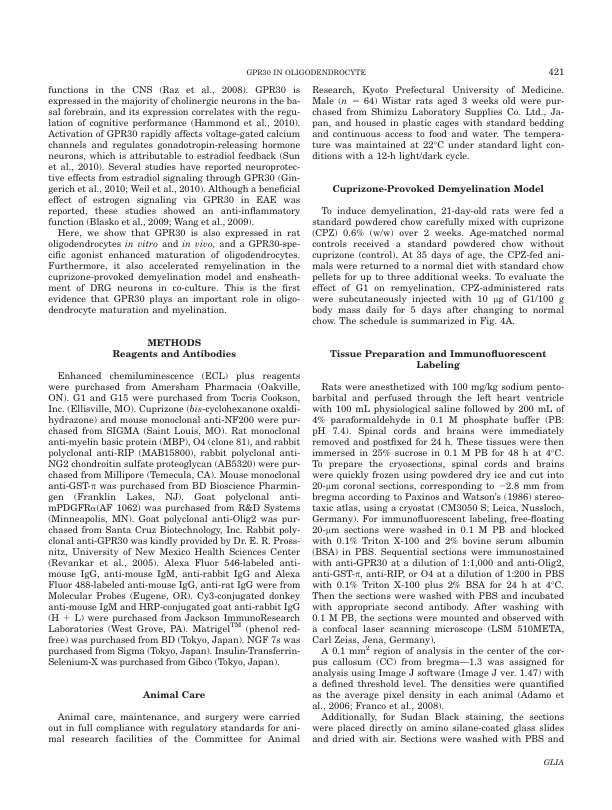

In [174]:
doc.pages[1].images[0]


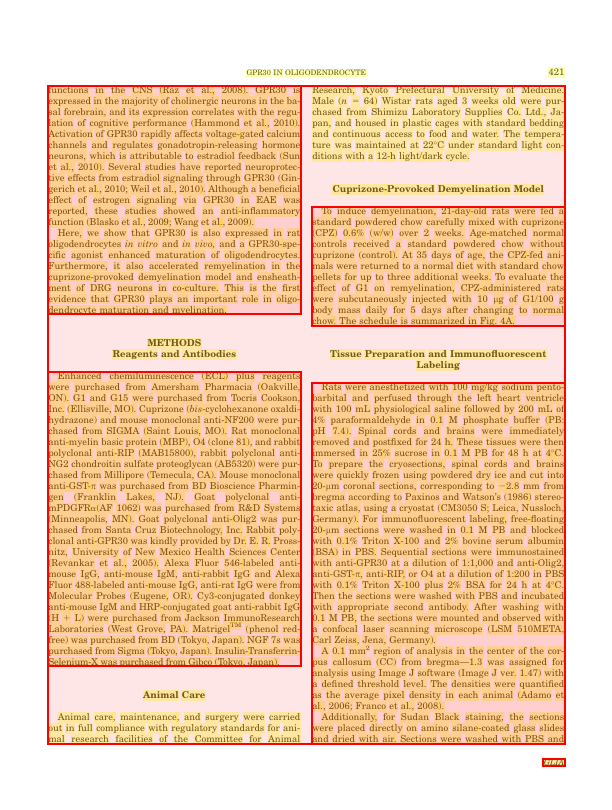

In [181]:
page = doc.pages[1]
highlighted = plot_entities_on_page(page.images[0], page.tokens, box_width=0, box_alpha=0.3, box_color="yellow")
highlighted = plot_entities_on_page(highlighted, page.paragraphs, box_width=2, box_alpha=0.1, box_color="red")
display(highlighted)

In [183]:
for section, paragraph in zip(doc.sections, doc.paragraphs):
    print("SECTION: ", section)
    print("PARAGRAPH: ", paragraph)
    print()
  

SECTION:  Annotated Entity:	ID: 0	Spans: True	Boxes: True	Text: INTRODUCTION
PARAGRAPH:  Annotated Entity:	ID: 0	Spans: True	Boxes: True	Text: Female steroid hormones have neuroprotective and promyelinating actions. Estrogen has been implicated in susceptibility to the neurological disease multiple sclero- sis (MS), in which the myelin sheath is destroyed in the brain and spinal cord. After puberty, MS occurs two times more frequently in females than in males, but undergoes remission during pregnancy (Czlonkowska et al., 2005; Hughes et al., 2004; McClain et al., 2007). To date, the effects of female steroid hormones have been studied in neurodegenerative and neuroinjury animal models, and clinical trials have been performed with estradiol and progesterone in MS and traumatic brain injury, respectively (Gibson et al., 2008; Trenova et al., 2004). Estrogen treatment ameliorates the disease manifestations of experimental allergic encephalomyeli- tis (EAE), and the cuprizone-provoked demy

# Langchain

In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_unstructured import UnstructuredLoader


In [72]:
#doc_path = "./output/formats/pdfs/0a5ab59cdc3d41b1a49e54a2fcf654fb.pdf"
#doc_path = "./output/formats/pdfs/0b9fba8a94374370919880ef5ecc8d72.pdf"
doc_path = "./output/formats/pdfs/0de24bf13c364edc90b1404ac837a614.pdf"


In [73]:
loader = PyPDFLoader(doc_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

In [74]:
pages[1]

Document(metadata={'producer': 'Acrobat Distiller 9.5.0 (Windows)', 'creator': '3B2 Total Publishing System 8.07e/W Unicode', 'creationdate': '2014-02-27T22:48:00+00:00', 'moddate': '2014-03-02T03:59:20+08:00', 'title': '', 'source': './output/formats/pdfs/0de24bf13c364edc90b1404ac837a614.pdf', 'total_pages': 8, 'page': 1, 'page_label': '307'}, page_content='endothelial cell permeability in larger vessels leads to\ndevelopment of interstitial edema and may result in\nenhancement of cell proliferation and matrix production\n[10].\nAdhesion molecules are believed to participate in the\npathogenesis of atherosclerosis [ 11]. These proteins\nregulate the interaction between the endothelium and the\nleukocytes, and an increase in their expression on the\nendothelial surface causes increased adhesion of leuko-\ncytes, particularly monocytes, which are well known as\none of theﬁrst steps in the process leading to atheroma\n[11]. In particular, over-expression of intracellular adhe-\nsion mole

In [75]:
materials_and_methods = []
capture = False

# Loop through each page's content
for page in pages:
    text = page.page_content
    #print(text)
    # Check for the start of the section
    if "Materials and Methods" in text:
        capture = True
    if capture:
        materials_and_methods.append(text)
        # Optionally, define an end condition if there's a specific end to the section
    # Example end condition:
    # if "References" in text:
    #     capture = False

# Combine the extracted section into a single string
materials_and_methods_text = "\n".join(materials_and_methods)

# Output or process the extracted text
print(materials_and_methods_text)


In [76]:
materials_and_methods

[]

In [77]:
loader_local = UnstructuredLoader(
    file_path=doc_path,
    strategy="hi_res",
)
docs_local = []
for doc in loader_local.lazy_load():
    docs_local.append(doc)

INFO: Reading PDF for file: ./output/formats/pdfs/0de24bf13c364edc90b1404ac837a614.pdf ...


In [78]:
len(docs_local)

140

In [79]:
docs_local[0].metadata.keys()
# docs_local[0].metadata['

dict_keys(['source', 'detection_class_prob', 'coordinates', 'last_modified', 'filetype', 'languages', 'page_number', 'file_directory', 'filename', 'category', 'element_id'])

In [84]:
docs_local[0].metadata['page_number']

1

In [80]:
docs_local[3].metadata['category']

'NarrativeText'

In [81]:
docs_local[2].page_content

'Wonhwa Lee,1,2 Sae-Kwang Ku,3 Doohyun Lee,1 Taeho Lee,1 and Jong-Sup Bae1,4'

In [152]:
def setup_logger(log_path):
    os.makedirs(os.path.dirname(log_path), exist_ok=True)

    logger = logging.getLogger("materials_methods_logger")
    logger.setLevel(logging.INFO)
    logger.propagate = False  # prevent duplicate logs to stdout

    # Clear previous handlers (if any)
    if logger.hasHandlers():
        logger.handlers.clear()

    file_handler = logging.FileHandler(log_path, mode='a')
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    return logger

def extract_materials_methods(
    doc_path,
    doc_id,
    log_path="./out_materials_methods/materials_methods.log",
    csv_text_path="./out_materials_methods/final_text.csv",
    csv_sections_path="./out_materials_methods/sections_text.csv"
):
    logger = setup_logger(log_path)
    os.makedirs(os.path.dirname(csv_text_path), exist_ok=True)
    os.makedirs(os.path.dirname(csv_sections_path), exist_ok=True)
    print(f"saving logs to {log_path}")
    logger.info(f"Reading PDF for file: {doc_path} ...")

    loader_local = UnstructuredLoader(
        file_path=doc_path,
        strategy="hi_res",
    )

    docs_local = []
    for doc in loader_local.lazy_load():
        docs_local.append(doc)

    MATERIALS_METHODS_TITLES = [
        r"materials\s*(and|&)\s*methods",
        r"methodology",
        r"experimental\s+(procedures|section)",
        r"methods",
    ]

    materials_methods_pattern = re.compile(
        r"^\s*(\d+\.?|\b[IVXLCDM]+\b\.?)?\s*(" + "|".join(MATERIALS_METHODS_TITLES) + r")\s*$",
        re.IGNORECASE
    )

    counter = Counter([doc.page_content.strip() for doc in docs_local])
    repeated_lines = {text for text, count in counter.items() if count > 3}

    sub_sections = defaultdict(list)
    save_subs_conent = False
    current_title = None

    for doc in docs_local:
        text = doc.page_content.strip()
        page_nr = doc.metadata.get("page_number", -1)

        if text in repeated_lines:
            continue

        if doc.metadata.get("category") == "Title":
            if materials_methods_pattern.search(text):
                save_subs_conent = True
                current_title = text
                logger.info(f"🧪 Detected section start: '{text}' on page {page_nr}")
                continue
            elif save_subs_conent:
                if "RESULTS" in text.upper() or "DISCUSSION" in text.upper() or "CONCLUSION" in text.upper():
                    save_subs_conent = False
                    logger.info(f"🔚 Stopping at section: '{text}' on page {page_nr}")
                    continue
                if current_title != text:
                    logger.info(f"📄 Subsection: '{text}' on page {page_nr}")
                current_title = text

        if save_subs_conent and doc.metadata.get("category") == "NarrativeText":
            sub_sections[current_title].append(text)

    # Create section-wise and full inline text
    section_rows = []
    final_text_parts = []

    for subsection in sorted(sub_sections):
        joined = " ".join(sub_sections[subsection])
        if len(joined) < 5: # skip sections which are less than 5 characters, likely parsing noise
            continue
        section_rows.append({
            "doc_id": doc_id,
            "Subsection": subsection,
            "Text": joined
        })
        final_text_parts.append(f"{subsection}\n{joined}")

    final_text_string = "\n\n".join(final_text_parts)

    df_sections = pd.DataFrame(section_rows)
    df_final = pd.DataFrame([{
        "doc_id": doc_id,
        "Text": final_text_string
    }])

    # Save both DataFrames to CSV
    df_final.to_csv(csv_text_path, index=False)
    df_sections.to_csv(csv_sections_path, index=False)

    logger.info("✅ Extraction and file saving complete.")

    return df_final, df_sections


In [153]:
# Set input and output folders
pdf_dir = "output/formats/pdfs"
output_text_dir = "out_materials_methods/batch/final_texts"
output_sections_dir = "out_materials_methods/batch/sections"
log_dir = "out_materials_methods"
log_path = os.path.join(log_dir, f"materials_methods_parsing.log")

# Make sure the output directories exist
os.makedirs(output_text_dir, exist_ok=True)
os.makedirs(output_sections_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Get all .pdf file paths
pdf_paths = glob.glob(os.path.join(pdf_dir, "*.pdf"))

# Process each PDF
for pdf_path in pdf_paths:
    # Use filename (without extension) as doc_id
    base_name = os.path.basename(pdf_path)
    doc_id = os.path.splitext(base_name)[0]

    print(f"🔄 Processing {doc_id}...")

    try:
        final_text_path = os.path.join(output_text_dir, f"{doc_id}_final_text.csv")
        sections_path = os.path.join(output_sections_dir, f"{doc_id}_sections.csv")

        # Skip if outputs already exist
        if os.path.exists(final_text_path) and os.path.exists(sections_path):
            print(f"⏭️ Skipping {doc_id} (already processed)")
            continue

        df_final, df_sections = extract_materials_methods(
            doc_path=pdf_path,
            doc_id=doc_id,
            csv_text_path=final_text_path,
            csv_sections_path=sections_path,
            log_path=log_path
        )

        print(f"✅ Done: {doc_id}")
    except Exception as e:
        print(f"❌ Error processing {doc_id}: {e}")

🔄 Processing 0de24bf13c364edc90b1404ac837a614...
saving logs to out_materials_methods/materials_methods_parsing.log


INFO: Reading PDF for file: output/formats/pdfs/0de24bf13c364edc90b1404ac837a614.pdf ...


✅ Done: 0de24bf13c364edc90b1404ac837a614
🔄 Processing 2ed936c0913848fdb02b3bb332653a3b...
saving logs to out_materials_methods/materials_methods_parsing.log


INFO: Reading PDF for file: output/formats/pdfs/2ed936c0913848fdb02b3bb332653a3b.pdf ...


✅ Done: 2ed936c0913848fdb02b3bb332653a3b
🔄 Processing 2bd57d3ecf904201b092b3e554dd8fbb...
saving logs to out_materials_methods/materials_methods_parsing.log


...

✅ Done: 01a0a4c68d9b4d6480c328a253e023ca
🔄 Processing 03cda2932f984d959dc4a9520013749d...
saving logs to out_materials_methods/materials_methods_parsing.log


INFO: Reading PDF for file: output/formats/pdfs/03cda2932f984d959dc4a9520013749d.pdf ...


✅ Done: 03cda2932f984d959dc4a9520013749d
🔄 Processing 2b787da417b745e19c1c4c32a324a49f...
saving logs to out_materials_methods/materials_methods_parsing.log


INFO: Reading PDF for file: output/formats/pdfs/2b787da417b745e19c1c4c32a324a49f.pdf ...


KeyboardInterrupt: 

In [156]:

doc_path = "./output/formats/pdfs/02dfd1462c7e412393336fe47a353b98.pdf"
docs_local = []
loader_local = UnstructuredLoader(
    file_path=doc_path,
    strategy="hi_res",
)
for doc in loader_local.lazy_load():
    docs_local.append(doc)


INFO: Reading PDF for file: ./output/formats/pdfs/02dfd1462c7e412393336fe47a353b98.pdf ...


In [165]:
MATERIALS_METHODS_TITLES = [
    r"materials\s*(and|&)\s*methods",
    r"methodology",
    r"experimental\s+(procedures|section)",
    r"methods",
]

# Accept things like "3. Experimental Section" or "III Experimental Section"
materials_methods_pattern = re.compile(
    r"^\s*(\d+\.?|[IVXLCDM]+\.)?\s*(" + "|".join(MATERIALS_METHODS_TITLES) + r")\b",
    re.IGNORECASE
)

counter = Counter([doc.page_content.strip() for doc in docs_local])
repeated_lines = {text for text, count in counter.items() if count > 3}

sub_sections = defaultdict(list)
save_subs_conent = False
current_title = None

for doc in docs_local:
    text = doc.page_content.strip()
    page_nr = doc.metadata.get("page_number", -1)

    if text in repeated_lines:
        continue

    if doc.metadata.get("category") == "Title":
        print(text)
        if materials_methods_pattern.search(text):
            save_subs_conent = True
            current_title = text
            print(f"🧪 Detected section start: '{text}' on page {page_nr}")
            continue
        elif save_subs_conent:
            if "RESULTS" in text.upper() or "DISCUSSION" in text.upper() or "CONCLUSION" in text.upper():
                save_subs_conent = False
                print(f"🔚 Stopping at section: '{text}' on page {page_nr}")
                continue
            if current_title != text:
                print(f"📄 Subsection: '{text}' on page {page_nr}")
            current_title = text

    if save_subs_conent and doc.metadata.get("category") == "NarrativeText":
        sub_sections[current_title].append(text)

# Create section-wise and full inline text
section_rows = []
final_text_parts = []

for subsection in sorted(sub_sections):
    joined = " ".join(sub_sections[subsection])
    section_rows.append({
        "doc_id": doc_id,
        "Subsection": subsection,
        "Text": joined
    })
    final_text_parts.append(f"{subsection}\n{joined}")

final_text_string = "\n\n".join(final_text_parts)

df_sections = pd.DataFrame(section_rows)
df_final = pd.DataFrame([{
    "doc_id": doc_id,
    "Text": final_text_string
}])


G Protein-Coupled Receptor 30 Contributes to Improved Remyelination After Cuprizone-Induced Demyelination
YUKIE HIRAHARA,1,2* KEN ICHI MATSUDA,1 HISAO YAMADA,2 AKIRA SAITOU,3 SHINSUKE MORISAKI,4 KEIKO TAKANAMI,1 JOAN M. BOGGS,5 AND MITSUHIRO KAWATA1
3Central Research Laboratory, Kansai Medical University, Osaka, Japan
KEY WORDS
ABSTRACT
INTRODUCTION
Cuprizone-Provoked Demyelination Model
METHODS Reagents and Antibodies
🧪 Detected section start: 'METHODS Reagents and Antibodies' on page 2
Tissue Preparation and Immunoﬂuorescent Labeling
📄 Subsection: 'Tissue Preparation and Immunoﬂuorescent Labeling' on page 2
Animal Care
📄 Subsection: 'Animal Care' on page 2
SDS-PAGE and Immunoblotting
📄 Subsection: 'SDS-PAGE and Immunoblotting' on page 3
Cultures
📄 Subsection: 'Cultures' on page 3
Oligodendrocyte primary cultures from neonatal rat spinal cord
📄 Subsection: 'Oligodendrocyte primary cultures from neonatal rat spinal cord' on page 3
Primary cultures of cortical oligodendrocytes and proge

In [164]:
df_final[['Text']]


,Text
0,Animal Care\nA 0.1 mm2 region of analysis in t...


In [166]:
df_sections

,doc_id,Subsection,Text
0,2b787da417b745e19c1c4c32a324a49f,Animal Care,A 0.1 mm2 region of analysis in the center of ...
1,2b787da417b745e19c1c4c32a324a49f,Electron Microscopy,"For electron microscopy, rats were perfused fr..."
2,2b787da417b745e19c1c4c32a324a49f,Immunocytochemistry,To study OPC differentiation and the pattern o...
3,2b787da417b745e19c1c4c32a324a49f,OPC-DRG neuron co-cultures,OPC-DRG neuron co-cultures were prepared as de...
4,2b787da417b745e19c1c4c32a324a49f,Oligodendrocyte primary cultures from neonatal...,Spinal cord oligodendrocytes were obtained fro...
5,2b787da417b745e19c1c4c32a324a49f,Primary cultures of cortical oligodendrocytes ...,Cerebral hemispheres from E18 rats were mechan...
6,2b787da417b745e19c1c4c32a324a49f,SDS-PAGE and Immunoblotting,The samples were resolved on 14% polyacrylamid...
7,2b787da417b745e19c1c4c32a324a49f,Tissue Preparation and Immunoﬂuorescent Labeling,Enhanced chemiluminescence (ECL) plus reagents...


In [167]:
df_sections.to_csv("Tempt.csv")